# The Effect Size Files: Focus Bean Tea Co.

**Author:** Jim Redden

AIPI 510 — Week 6 Assignment: Hypothesis-driven study design to test a client's claim, including a power analysis for required sample size.


## Client Claim

**Client:** Focus Bean Tea Co.

**Claim:** "Drinking our mushroom-based tea improves reaction time by 20ms on cognitive tests after just one week."

**Outcome measure:** Reaction time, in milliseconds (ms) — a continuous variable, measured via a standardized cognitive (reaction-time) test, after one week of daily tea consumption.

**Claimed effect:** A 20ms reduction in reaction time (faster response) relative to baseline/control after one week of use.

**Assumptions** Since the claim is ambiguous, I am assuming that this claim compares an individual's reaction time to that individuals own baseline (requiring comparing before and after measurements as the key to our analysis.) 


## Hypotheses



**Null hypothesis (H0):**

$$H_0: \mu_{\text{diff}} = 0$$

The mean difference in reaction time before and after the intervention is zero. Said plainly: drinking mushroom-based tea at the recommended dose for one week creates no measurable difference in reaction time.

**Alternative hypothesis (H1):**

$$H_1: \mu_{\text{diff}} \neq 0$$

The mean difference in reaction time before and after the intervention is non-zero. Said plainly: drinking mushroom-based tea at the recommended dose for one week has a measurable impact on reaction time (two-tailed — we are not assuming in advance that the tea can only help).

**Sign convention:** For each participant $i$, let $d_i = \text{RT}_{\text{before},i} - \text{RT}_{\text{after},i}$ (reaction time in ms before the one-week tea intervention minus reaction time after). A positive $d_i$ means reaction time *decreased* (improved/got faster). Let $\mu_{\text{diff}} = E[d_i]$ be the population mean of these paired differences.

## Statistical Test

**Test:** Paired-samples (dependent-samples) t-test.

**Why it fits:** This is a within-subjects design — the same participants' reaction time is measured twice (before and after one week of tea use), so the two measurements per person are correlated, not independent. The outcome (reaction time, ms) is continuous. Pairing removes between-subject variability (e.g., some people are just naturally faster) from the error term, which is exactly the paired t-test's purpose and gives it more power than treating before/after as two independent groups. I considered a one sided t test and that aligns with the claim that it improves - but why not design a test to measure and see if there is significant negative effect? So I'm using the the two sided t-test in my design.

Test statistic:

$$t = \frac{\bar{d} - \mu_{\text{diff}}}{s_d / \sqrt{n}}$$

where $\bar{d}$ is the sample mean of the paired differences, $\mu_{\text{diff}} = 0$ under $H_0$, $s_d$ is the standard deviation of the differences, and $n$ is the number of participants.

In Python: `scipy.stats.ttest_rel(reaction_time_before, reaction_time_after)` (two-sided by default, matching our H1).




## Literature Review: Effect Size

Since this is a before/after design on the same people, the effect size I need is Cohen's $d_z$ — the average change divided by how spread out those change numbers are ($s_d$). That's not the same as a regular Cohen's d for two separate groups, since there's only one group here, just measured twice.

I found a paper that's a pretty good match: La Monica et al. (2023) in *Nutrients*. It's a double-blind, randomized, placebo-controlled study on 40 healthy adults, testing a Lion's Mane mushroom extract and a Guayusa tea extract on reaction time (Go/No-go and N-Back tasks) at baseline, 60 min, and 120 min. For the Lion's Mane group, reaction time got about 9ms faster (p = 0.036, d = 0.41) from baseline to 120 min, and about 8ms faster (p = 0.004, d = 0.54) from 60 min to 120 min. The N-Back task showed a similar ~9.5ms improvement (d = 0.39).

Citation: La Monica, M. B., Raub, B., Ziegenfuss, E. J., et al. (2023). Acute Effects of Naturally Occurring Guayusa Tea and Nordic Lion's Mane Extracts on Cognitive Performance. *Nutrients*, 15(24), 5018. https://doi.org/10.3390/nu15245018

This study measured an acute effect — within 2 hours of one dose — not what happens after a full week of drinking tea every day like Focus Bean is claiming. It also used a concentrated mushroom extract, not a consumer tea you'd actually buy off a shelf, which is probably a weaker, less consistent dose. Those two things pull in opposite directions (a week of daily use could help more; a weaker real-world dose could help less).

So I landed on **d = 0.4**, roughly the middle of the three Lion's Mane numbers they reported (0.39, 0.41, 0.54). For context, Focus Bean's own claim of a 20ms improvement would need a d of about 0.87 if the noise in a real study looked like this paper's — so their claim is already bigger than the best real study I could find, which I'll come back to in the Rationale section.

Another note: our borrowed effect size might be overly optimistic, because it came from a same-day, low-noise measurement, while our actual study spans a week and will probably be noisier than that.


## Power Analysis

Calculate the required sample size given the effect size from the literature, a chosen significance level (alpha), and desired power.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestPower

# settings -- match the Hypotheses and Statistical Test sections above
alpha = 0.05                # standard significance threshold, chosen before looking at any data
power_target = 0.80         # standard target power (20% chance of missing a real effect)
alternative = "two-sided"   # matches H1: mu_diff != 0

# effect size from the Literature Review section: d_z = 0.4 (Lion's Mane, La Monica et al. 2023)
effect_size = 0.4

# using TTestPower, not TTestIndPower -- this is a paired design, one group of
# participants each measured twice, so the power analysis is really a
# one-sample test on the before/after difference scores.
analysis = TTestPower()

n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power_target, alternative=alternative)
n = int(np.ceil(n))
print(f"Required number of participants: {n}")


Required number of participants: 52


In [2]:
# real studies lose people over a week (forgot the retest, dropped out, etc.) --
# padding the recruitment number accounts for that
dropout_rate = 0.10
n_recruit = int(np.ceil(n / (1 - dropout_rate)))
print(f"Recruiting with a {int(dropout_rate * 100)}% dropout buffer: {n_recruit} participants")


Recruiting with a 10% dropout buffer: 58 participants


In [3]:
# how much does the answer move if I'm wrong about the effect size?
# (0.2-0.3 = noisier week-long study, 0.4 = what I used, 0.5-0.54 = paper's upper end, 0.87 = Focus Bean's claim)
for d in [0.2, 0.3, 0.4, 0.5, 0.54, 0.87]:
    n_d = analysis.solve_power(effect_size=d, alpha=alpha, power=power_target, alternative=alternative)
    n_d = int(np.ceil(n_d))
    print(f"d = {d:.2f} -> required participants = {n_d}")


d = 0.20 -> required participants = 199
d = 0.30 -> required participants = 90
d = 0.40 -> required participants = 52
d = 0.50 -> required participants = 34
d = 0.54 -> required participants = 29
d = 0.87 -> required participants = 13


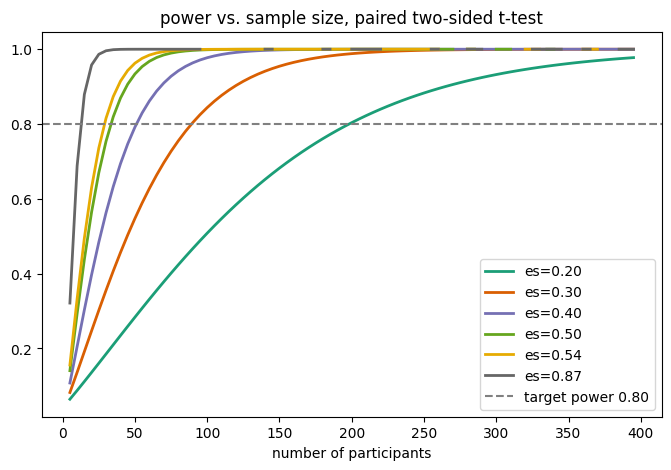

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
analysis.plot_power(dep_var="nobs", nobs=np.arange(5, 400, 5),
                     effect_size=[0.2, 0.3, 0.4, 0.5, 0.54, 0.87],
                     alpha=alpha, alternative=alternative, ax=ax)
ax.axhline(power_target, color="gray", linestyle="--", label="target power 0.80")
ax.set_xlabel("number of participants")
ax.set_title("power vs. sample size, paired two-sided t-test")
ax.legend()
plt.show()


In [5]:
# Focus Bean's 20ms claim is fixed here -- how does the IMPLIED effect size (and the n
# needed to detect it) change across the range of plausible SDs our literature review turned up?
#   ~20-25ms  -> La Monica's same-day, low-noise result (the optimistic case we used above)
#   ~70-90ms  -> reconstructed test-retest SD from Lamb et al.'s simple/choice RT tasks (the "real study is noisier" worry)
claimed_effect_ms = 20
plausible_sds = [20, 23, 30, 40, 50, 69.5, 89, 100]

for sd in plausible_sds:
    implied_d = claimed_effect_ms / sd
    n_needed = int(np.ceil(analysis.solve_power(effect_size=implied_d, alpha=alpha, power=power_target, alternative=alternative)))
    print(f"SD = {sd:>5.1f} ms -> implied d = {implied_d:.2f} -> required participants = {n_needed}")


SD =  20.0 ms -> implied d = 1.00 -> required participants = 10
SD =  23.0 ms -> implied d = 0.87 -> required participants = 13
SD =  30.0 ms -> implied d = 0.67 -> required participants = 20
SD =  40.0 ms -> implied d = 0.50 -> required participants = 34
SD =  50.0 ms -> implied d = 0.40 -> required participants = 52
SD =  69.5 ms -> implied d = 0.29 -> required participants = 97
SD =  89.0 ms -> implied d = 0.22 -> required participants = 158
SD = 100.0 ms -> implied d = 0.20 -> required participants = 199


## Rationale

**Design and hypotheses.** We treated Focus Bean's claim as a within-subjects comparison — the same participants measured before and after one week of daily tea use — rather than two separate groups with a control arm. This matches how the claim itself is stated (an individual's own improvement, not a group comparison) and gives more statistical power than a between-subjects design would, since pairing removes between-person variability (e.g. naturally fast vs. slow reactors) from the error term. Had we used a between-subjects design instead, we would have had to assume random assignment produced two comparable groups at baseline, and we would have needed a larger sample to reach the same power, since we'd lose that pairing advantage.

We set $H_1$ as two-sided ($\mu_{\text{diff}} \neq 0$) rather than directional, so the test could also flag a significant *negative* effect, not just the claimed direction — we didn't want to assume in advance that the tea could only help. The cost of that choice is a larger required sample than a one-sided test would need for the same power; if budget were a hard constraint, switching to one-sided is the first lever to revisit.

**Statistical test.** A paired-samples t-test is the right choice because the same participants are measured twice, so their before and after scores are correlated by everything that makes that person who they are — an independent-samples t-test assumes no such correlation, which is clearly violated here. The test statistic is built from each participant's own difference score, $d_i = \text{RT}_{\text{before},i} - \text{RT}_{\text{after},i}$, with a positive value defined as improvement (faster reaction time).

**Effect size.** Because this is a paired design, the matching effect size is Cohen's $d_z$: the mean of the individual difference scores divided by the standard deviation of those difference scores. This differs from the standard two-group Cohen's d, which divides the gap between two separate group means by the pooled standard deviation of both groups' raw scores — that formula doesn't apply here, since there is only one group of people, not two.

We estimated $d_z$ from La Monica et al. (2023), a placebo-controlled crossover trial testing a Lion's Mane extract on reaction time, which reported three $d$ values for the Lion's Mane condition (0.39, 0.41, 0.54). We used the middle value, **d = 0.4**, rather than the largest or smallest, as the more conservative choice. We discounted this estimate for two reasons: the paper measured an acute effect (within two hours of a single dose) rather than the chronic, one-week effect Focus Bean claims, and it used a concentrated extract rather than a weaker consumer tea — both of which make the paper's effect size an uncertain stand-in for ours.

Focus Bean's own 20ms claim implies a $d \approx 0.87$ under this paper's noise assumptions — nearly double the best real effect size we could find in the literature. That gap is itself worth flagging to the client: a claim implying a substantially larger effect than the best available peer-reviewed evidence is a reason to be skeptical of the claim, not just a convenient number to plan around.

**Power analysis.** We used `statsmodels`' `TTestPower`, not `TTestIndPower`, because a paired t-test is mathematically equivalent to a one-sample t-test performed on the difference scores — `TTestPower` is the function built for that one-sample/paired case. With $\alpha = 0.05$ (standard, chosen before collecting any data) and power = 0.80 (standard; accepting a 20% chance of missing a real effect), and d = 0.4, the required sample size is **52 participants**. We added a 10% dropout buffer, bringing the recruiting target to **58**. A stricter alpha (e.g. 0.01) would require a larger sample for the same power, since the test needs a more extreme result to count as significant.

**Sensitivity analysis.** Required sample size is highly sensitive to the assumed effect size: across the plausible range we considered (d = 0.2, reflecting a noisier week-long design, up to d = 0.87, Focus Bean's own claim), the required sample ranged from 199 down to 13 participants. We checked this a second way too, holding the claimed 20ms effect fixed and varying the assumed standard deviation across the range our broader literature search turned up (~20ms to ~100ms); the same 20ms effect requires anywhere from 10 to 199 participants depending on that assumption.

**Recommendation.** We recommend Focus Bean proceed with a target of 58 participants (52 plus dropout buffer), based on our conservative literature-derived estimate of d = 0.4. We flag this as a real trade-off, not a guarantee: our sensitivity analysis shows this sample would be underpowered if the true effect is smaller than d = 0.4 (plausible if real-world noise is closer to the higher end of our literature range), and overpowered if the true effect is as large as Focus Bean's own claim. Given that uncertainty, we'd advise running a small pilot study first to get a real effect-size estimate from this specific product and task, rather than committing the full budget on a borrowed number from an unrelated study.
